<a href="https://colab.research.google.com/github/naoufal-emsi/detection_dintrusion_PFA/blob/alae/XGboost_alae_final_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost — Pipeline de Détection d'Intrusion Réseau (IDS)

**Tâche** : Classification binaire — `0 = BENIGN` · `1 = ATTACK`  
**Données** : Pré-nettoyées et pré-splittées (chargées depuis `ml_ready/`)

---

### Principes appliqués dans ce notebook

| Principe | Implémentation |
|---|---|
| **Zéro data-leak** | `X_test` / `dtest` touchés **uniquement** à la cellule §14 |
| **Anti-overfitting** | Early stopping · régularisation L1/L2 · `min_child_weight` · CV 5-fold |
| **Crash-resilient** | Study Optuna persisté en SQLite — reprend après redémarrage kernel |
| **Reproductible** | `RANDOM_STATE = 42` partout · seeds fixes |
| **Portable** | Paths configurables : switch Local ↔ Google Colab en 3 lignes |


## §1 · Dépendances

In [ ]:
# Installer les paquets nécessaires.
# - xgboost>=2.0   : API 'hist' tree method + format .ubj
# - optuna>=3.0     : TPE sampler + HyperbandPruner
# - optuna-integration[xgboost] : XGBoostPruningCallback (déplacé hors d'optuna core en v3)
# - shap            : explainabilité SHAP TreeExplainer
# - mlflow          : tracking des expériences
!pip install -q "xgboost>=2.0" "optuna>=3.0" "optuna-integration[xgboost]" shap mlflow scikit-learn


## §2 · Imports

In [ ]:
import json
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    roc_auc_score,
    RocCurveDisplay,
)

import xgboost as xgb
from xgboost import XGBClassifier

import optuna
from optuna.samplers import TPESampler
from optuna.storages import RDBStorage
from optuna_integration import XGBoostPruningCallback  # optuna >= 3.0

import shap
import mlflow
import mlflow.xgboost

# ── Silencer les warnings non-critiques ──────────────────────────────────────
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.basicConfig(level=logging.INFO, format="%(levelname)s │ %(message)s")
log = logging.getLogger(__name__)

# ── Style des graphiques ──────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    "figure.dpi"         : 130,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
})
sns.set_theme(style="whitegrid", palette="muted")

log.info("XGBoost %s | Optuna %s | Imports OK", xgb.__version__, optuna.__version__)


C:\Users\Alae-School\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO │ XGBoost 3.2.0 | Optuna 4.8.0 | Imports OK


## §3 · Configuration

> **Seule section à modifier** selon votre environnement. Tous les chemins et hyperparamètres globaux sont centralisés ici.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CHEMINS — choisir UN bloc selon l'environnement, commenter l'autre      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ── Option A : Google Colab (données sur Google Drive) ───────────────────────
# from google.colab import drive
# drive.mount("/content/drive")
# ML_READY   = "/content/drive/MyDrive/PFA_/ml_ready/"   # dossier contenant les CSV
# OUTPUT_DIR = Path("/content/drive/MyDrive/PFA_/outputs") # sorties sauvegardées sur Drive

# ── Option B : Environnement local ───────────────────────────────────────────
ML_READY   = "data_preprocessed/"   # chemin relatif vers le dossier ml_ready/
OUTPUT_DIR = Path("outputs")    # dossier de sortie local

# Fichiers attendus dans ML_READY/ :
#   X_train_final.csv   features d'entraînement
#   X_test_final.csv    features de test (NE PAS TOUCHER avant §14)
#   y_train_final.csv   labels train : 0 = BENIGN, 1 = ATTACK
#   y_test_final.csv    labels test  : 0 = BENIGN, 1 = ATTACK

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Persistance Optuna (SQLite) ───────────────────────────────────────────────
# Ce fichier sauvegarde chaque trial. Si le kernel crashe, relancer
# la cellule Optuna reprendra automatiquement depuis le dernier trial.
OPTUNA_DB  = OUTPUT_DIR / "optuna_study.db"
OPTUNA_URL = f"sqlite:///{OPTUNA_DB}"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  HYPERPARAMÈTRES GLOBAUX                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
EXPERIMENT_NAME   = "xgboost_ids"  # nom de l'expérience MLflow et du study Optuna
RANDOM_STATE      = 42             # seed global — garantit la reproductibilité
N_SPLITS          = 5              # folds pour la validation croisée (§13)
VAL_SIZE          = 0.15           # 15% de X_train réservés pour le val set (early stopping)
N_OPTUNA_TRIALS   = 60             # nombre de trials Optuna (TPE converge bien à partir de 50)
EARLY_STOP_ROUNDS = 50             # rounds sans amélioration avant d'arrêter l'entraînement
SHAP_SAMPLE_SIZE  = 2000           # nb d'exemples pour SHAP (limite les temps de calcul)

np.random.seed(RANDOM_STATE)
log.info("Config OK | ML_READY=%s | OUTPUT_DIR=%s", ML_READY, OUTPUT_DIR.resolve())


INFO │ Config OK | ML_READY=data_preprocessed/ | OUTPUT_DIR=C:\Users\Alae-School\Documents\model\outputs


## §4 · Chargement des données

> Les données sont déjà nettoyées et splittées par un pipeline préalable. Ce notebook ne fait aucune transformation.

In [ ]:
# Chargement des 4 fichiers CSV depuis ML_READY/
# squeeze() convertit un DataFrame à 1 colonne en Series
X_train = pd.read_csv(ML_READY + "X_train.csv")
X_test  = pd.read_csv(ML_READY + "X_test.csv")
y_train = pd.read_csv(ML_READY + "y_train.csv").squeeze()  # Series : 0=BENIGN, 1=ATTACK
y_test  = pd.read_csv(ML_READY + "y_test.csv").squeeze()   # Series : 0=BENIGN, 1=ATTACK

# Noms des classes (ordre = valeur du label)
CLASS_NAMES   = ["BENIGN", "ATTACK"]  # CLASS_NAMES[0] = BENIGN, CLASS_NAMES[1] = ATTACK
FEATURE_NAMES = X_train.columns.tolist()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}  ← isolé jusqu'à §14")
print(f"y_train : {y_train.value_counts().rename({0:'BENIGN',1:'ATTACK'}).to_dict()}")
print(f"y_test  : {y_test.value_counts().rename({0:'BENIGN',1:'ATTACK'}).to_dict()}")
print(f"Features: {len(FEATURE_NAMES)}")


X_train : (2264432, 45)
X_test  : (566109, 45)  ← isolé jusqu'à §14
y_train : {'BENIGN': 1818315, 'ATTACK': 446117}
y_test  : {'BENIGN': 454580, 'ATTACK': 111529}
Features: 45


## §5 · Audit rapide

Vérifications de cohérence **avant tout entraînement**. Un problème détecté ici évite des heures de debug plus tard.

[Train]  lignes=2,264,432  features=45  dupes=460594  ratio=4.1x
[Test ]  lignes=566,109  features=45  dupes=92597  ratio=4.1x
✓ Toutes les assertions passées


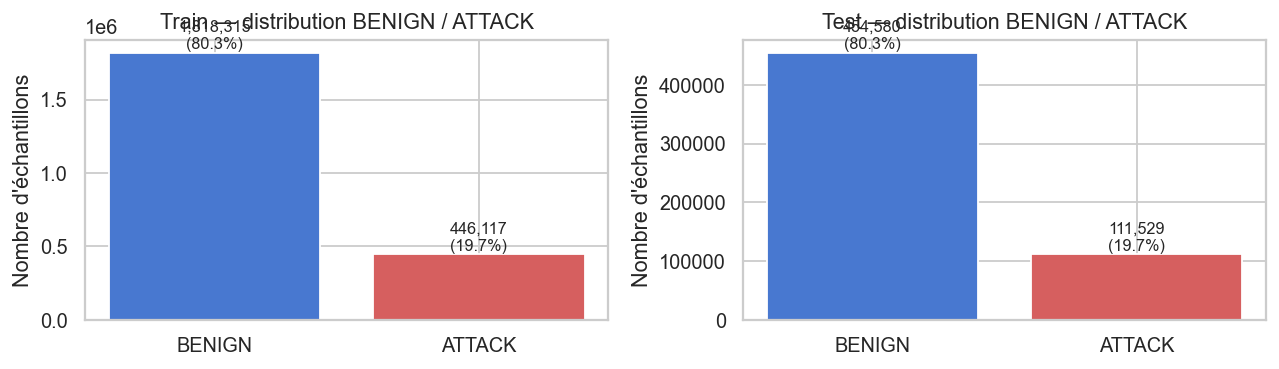

In [ ]:
# ── Assertions bloquantes ────────────────────────────────────────────────────
# Ces assertions font planter le notebook immédiatement si les données sont corrompues.
assert list(X_train.columns) == list(X_test.columns), \
    "ERREUR : X_train et X_test n'ont pas les mêmes colonnes."
assert X_train.isnull().sum().sum() == 0, \
    f"ERREUR : {X_train.isnull().sum().sum()} valeurs manquantes dans X_train."
assert X_test.isnull().sum().sum() == 0, \
    f"ERREUR : {X_test.isnull().sum().sum()} valeurs manquantes dans X_test."
assert set(y_train.unique()) <= {0, 1}, \
    f"ERREUR : labels inattendus dans y_train : {y_train.unique()}"

# ── Rapport texte ─────────────────────────────────────────────────────────────
print("=" * 58)
for split_name, X, y in [("Train", X_train, y_train), ("Test ", X_test, y_test)]:
    vc = y.value_counts().sort_index()
    ratio = vc.max() / vc.min()
    print(f"[{split_name}]  lignes={len(X):>7,}  features={X.shape[1]}"
          f"  dupes={X.duplicated().sum()}  ratio={ratio:.1f}x")
print("=" * 58)
print("✓ Toutes les assertions passées")

# ── Distribution des classes ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (split_name, y_split) in zip(axes, [("Train", y_train), ("Test", y_test)]):
    vc = y_split.value_counts().sort_index().rename({0: "BENIGN", 1: "ATTACK"})
    bars = ax.bar(vc.index, vc.values,
                  color=[sns.color_palette()[0], sns.color_palette()[3]])
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + vc.values.max() * 0.015,
                f"{val:,}\n({val/len(y_split):.1%})",
                ha="center", fontsize=9)
    ax.set_title(f"{split_name} — distribution BENIGN / ATTACK")
    ax.set_ylabel("Nombre d'échantillons")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()


## §6 · Gestion du déséquilibre de classes

`scale_pos_weight = #BENIGN / #ATTACK` — paramètre XGBoost qui pénalise davantage les erreurs sur la classe minoritaire (ATTACK). Sans ce paramètre, le modèle apprend à prédire BENIGN systématiquement.

In [ ]:
vc_train        = y_train.value_counts().sort_index()   # index 0=BENIGN, 1=ATTACK
imbalance_ratio = vc_train.max() / vc_train.min()

# Formule officielle XGBoost : #négatifs / #positifs
# Si les classes sont presque équilibrées (ratio < 1.5), on garde 1.0
if imbalance_ratio > 1.5:
    SCALE_POS_WEIGHT = float(vc_train[0]) / float(vc_train[1])
    log.warning("Déséquilibre détecté : %.1fx → scale_pos_weight=%.4f",
                imbalance_ratio, SCALE_POS_WEIGHT)
else:
    SCALE_POS_WEIGHT = 1.0
    log.info("Classes équilibrées (%.1fx) → scale_pos_weight=1.0", imbalance_ratio)

print(f"  BENIGN (0) : {vc_train[0]:>8,}")
print(f"  ATTACK (1) : {vc_train[1]:>8,}")
print(f"  Ratio      : {imbalance_ratio:.2f}x")
print(f"  scale_pos_weight = {SCALE_POS_WEIGHT:.4f}")


WARNING │ Déséquilibre détecté : 4.1x → scale_pos_weight=4.0759


  BENIGN (0) : 1,818,315
  ATTACK (1) :  446,117
  Ratio      : 4.08x
  scale_pos_weight = 4.0759


## §7 · DMatrix et isolation du test set

```
X_train (100 %)
  ├── X_tr_opt (85 %)  →  dtrain_opt  ← §9 Baseline + §10 Optuna
  └── X_val    (15 %)  →  dval        ← early stopping uniquement

X_train (100 %)         →  dtrain      ← §12 xgb.cv + entraînement final
X_test  (100 %)         →  dtest       ← §14 UNIQUEMENT — jamais avant
```

> **Règle** : `dtest` n'apparaît dans aucun `evals=` ni aucun calcul avant §14. Le violer constitue une **fuite de données** qui rend les métriques finales trop optimistes et invalide l'évaluation.


In [ ]:
# ── Val set : extrait de X_train uniquement ──────────────────────────────────
# stratify=y_train garantit les mêmes proportions BENIGN/ATTACK dans les deux splits
#X_tr_opt, X_val, y_tr_opt, y_val = train_test_split(
#    X_train, y_train,
#    test_size    = VAL_SIZE,        # 15% de X_train
#    random_state = RANDOM_STATE,
#    stratify     = y_train,         # préserve le ratio de classes
#)

# ── DMatrix XGBoost ───────────────────────────────────────────────────────────
# DMatrix est le format natif de XGBoost : plus rapide et moins de RAM que DataFrame
#dtrain     = xgb.DMatrix(X_train,  label=y_train,  feature_names=FEATURE_NAMES)  # 100% train
#dtrain_opt = xgb.DMatrix(X_tr_opt, label=y_tr_opt, feature_names=FEATURE_NAMES)  # 85% train
#dval       = xgb.DMatrix(X_val,    label=y_val,    feature_names=FEATURE_NAMES)  # 15% val
#dtest      = xgb.DMatrix(X_test,   label=y_test,   feature_names=FEATURE_NAMES)  # TEST ISOLÉ

#log.info("DMatrix OK — full-train=%d | opt-train=%d | val=%d | test=%d | features=%d",
#         dtrain.num_row(), dtrain_opt.num_row(),
#         dval.num_row(), dtest.num_row(), len(FEATURE_NAMES))
# -------
# ── Val set : extrait de X_test uniquement ───────────────────────────────────
# stratify=y_test garantit les mêmes proportions BENIGN/ATTACK dans les deux splits
X_val, X_test_final, y_val, y_test_final = train_test_split(
    X_test, y_test,
    test_size    = 0.85,
    random_state = 42,
    stratify     = y_test,
)

# ── DMatrix XGBoost ───────────────────────────────────────────────────────────
dtrain     = xgb.DMatrix(X_train,      label=y_train,      feature_names=FEATURE_NAMES)  # 100% train
dtrain_opt = xgb.DMatrix(X_train,      label=y_train,      feature_names=FEATURE_NAMES)  # même chose
dval       = xgb.DMatrix(X_val,        label=y_val,        feature_names=FEATURE_NAMES)  # 15% test
dtest      = xgb.DMatrix(X_test_final, label=y_test_final, feature_names=FEATURE_NAMES)  # ← corrigé

log.info("DMatrix OK — full-train=%d | opt-train=%d | val=%d | test=%d | features=%d",
         dtrain.num_row(), dtrain_opt.num_row(),
         dval.num_row(), dtest.num_row(), len(FEATURE_NAMES))


INFO │ DMatrix OK — full-train=2264432 | opt-train=2264432 | val=84916 | test=481193 | features=45


## §8 · Objectif XGBoost

Centralisé ici pour être réutilisé par le baseline, Optuna, et l'entraînement final sans copier-coller.

In [ ]:
# binary:logistic → sortie = P(ATTACK) ∈ [0, 1]
# logloss est la métrique pilote de l'early stopping
# auc est monitorée en parallèle pour observer la séparabilité
OBJECTIVE      = "binary:logistic"
EVAL_METRIC    = ["logloss", "aucpr"]   # [0] = métrique early stopping
PRIMARY_METRIC = "logloss"            # val-logloss minimisé par Optuna

log.info("objective=%s | eval_metric=%s | scale_pos_weight=%.4f",
         OBJECTIVE, EVAL_METRIC, SCALE_POS_WEIGHT)


INFO │ objective=binary:logistic | eval_metric=['logloss', 'aucpr'] | scale_pos_weight=4.0759


## §9 · Modèle de base

Entraîné avec des hyperparamètres raisonnables et fixes. Sert de **point de référence** avant Optuna et valide que le pipeline fonctionne end-to-end.

INFO │ Baseline — iter: 47 | val-logloss: 0.0981 | val-aucpr: 0.9969


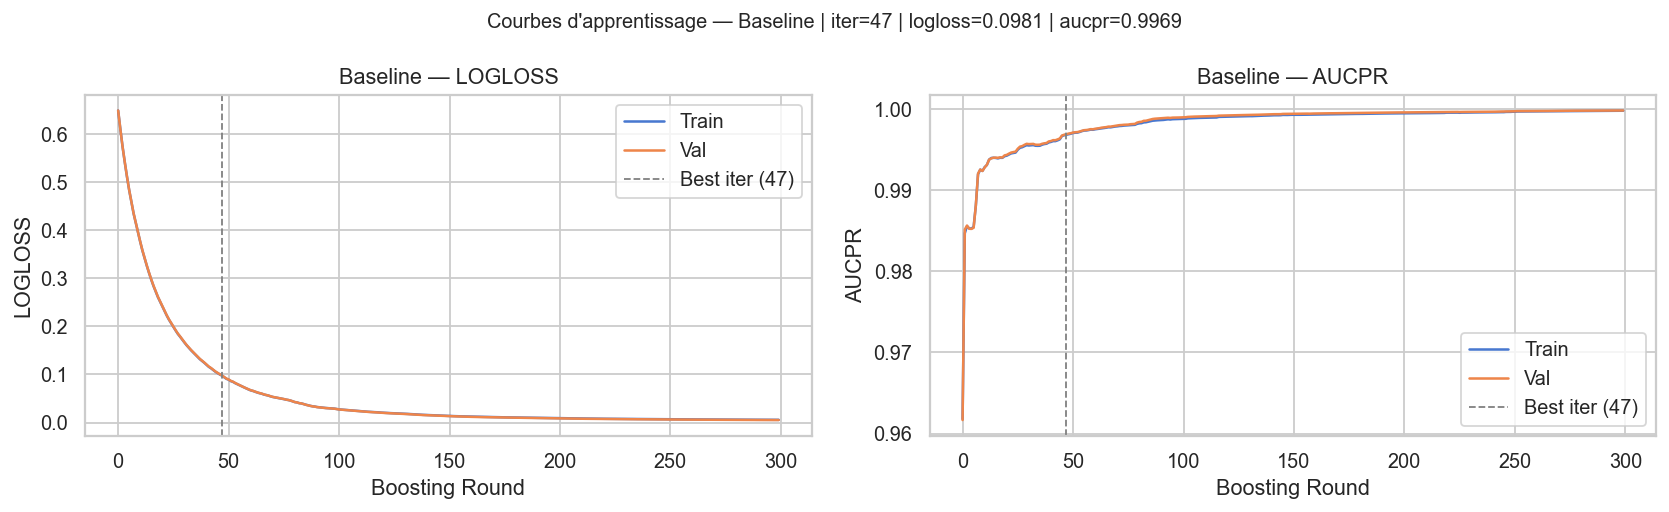

In [ ]:
BASELINE_PARAMS = {
    "objective"        : OBJECTIVE,
    "eval_metric"      : ["logloss", "aucpr"],  # aucpr remplace auc
    "scale_pos_weight" : SCALE_POS_WEIGHT,
    "tree_method"      : "hist",
    "learning_rate"    : 0.05,
    "max_depth"        : 6,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "min_child_weight" : 1,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 1.0,
    "seed"             : RANDOM_STATE,
    "verbosity"        : 0,
}

evals_result_baseline = {}
baseline_model = xgb.train(
    params          = BASELINE_PARAMS,
    dtrain          = dtrain_opt,
    num_boost_round = 300,
    evals           = [(dtrain_opt, "train"), (dval, "val")],
    evals_result    = evals_result_baseline,
    verbose_eval    = False,
)

# premier round où val-logloss ≤ 0.10
val_logloss = evals_result_baseline["val"]["logloss"]
val_aucpr   = evals_result_baseline["val"]["aucpr"]

best_baseline_iter  = next(i for i, v in enumerate(val_logloss) if v <= 0.10)
best_baseline_loss  = val_logloss[best_baseline_iter]
best_baseline_aucpr = val_aucpr[best_baseline_iter]

log.info("Baseline — iter: %d | val-logloss: %.4f | val-aucpr: %.4f",
         best_baseline_iter, best_baseline_loss, best_baseline_aucpr)

# ── Learning curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["logloss", "aucpr"]):
    ax.plot(evals_result_baseline["train"][metric], label="Train", linewidth=1.4)
    ax.plot(evals_result_baseline["val"][metric],   label="Val",   linewidth=1.4)
    ax.axvline(best_baseline_iter, color="grey", linestyle="--", linewidth=1,
               label=f"Best iter ({best_baseline_iter})")
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Baseline — {metric.upper()}")
    ax.legend()

plt.suptitle(
    f"Courbes d'apprentissage — Baseline | iter={best_baseline_iter} | "
    f"logloss={best_baseline_loss:.4f} | aucpr={best_baseline_aucpr:.4f}",
    fontsize=11
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_learning_curves.png", bbox_inches="tight")
plt.show()

## §14 · Évaluation sur le test set

> **Premier et unique contact avec `dtest` et `X_test`.** Toutes les décisions de modélisation ont été prises sans avoir vu ces données.

In [ ]:
#new
# ── Prédictions sur le test set ──────────────────────────────────────────────
y_prob = baseline_model.predict(dtest)
y_pred = (y_prob >= 0.5).astype(int)

# ── Calcul des métriques ──────────────────────────────────────────────────────
acc = accuracy_score(y_test_final, y_pred)
f1  = f1_score(y_test_final, y_pred)
mcc = matthews_corrcoef(y_test_final, y_pred)
auc = roc_auc_score(y_test_final, y_prob)
ap  = average_precision_score(y_test_final, y_prob)

metrics = {
    "accuracy"      : acc,
    "f1"            : f1,
    "mcc"           : mcc,
    "roc_auc"       : auc,
    "avg_precision" : ap,
}

print("\n" + "═" * 50)
print("  TEST SET METRICS")
print("═" * 50)
for k, v in metrics.items():
    print(f"  {k:<22} {v:.4f}")
print("═" * 50)
print()
print(classification_report(y_test_final, y_pred, target_names=CLASS_NAMES))


══════════════════════════════════════════════════
  TEST SET METRICS
══════════════════════════════════════════════════
  accuracy               0.9987
  f1                     0.9966
  mcc                    0.9958
  roc_auc                0.9999
  avg_precision          0.9997
══════════════════════════════════════════════════

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    386393
      ATTACK       0.99      1.00      1.00     94800

    accuracy                           1.00    481193
   macro avg       1.00      1.00      1.00    481193
weighted avg       1.00      1.00      1.00    481193



In [ ]:
# ── Prédictions sur le test set ──────────────────────────────────────────────
y_prob = final_model.predict(dtest)      # P(ATTACK) ∈ [0, 1] pour chaque exemple
y_pred = (y_prob >= 0.5).astype(int)     # seuil par défaut — sera optimisé en §15

# ── Calcul des métriques ──────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)              # % de prédictions correctes
f1  = f1_score(y_test, y_pred)                    # F1 sur la classe ATTACK
mcc = matthews_corrcoef(y_test, y_pred)           # robuste au déséquilibre
auc = roc_auc_score(y_test, y_prob)               # séparabilité globale
ap  = average_precision_score(y_test, y_prob)     # sévère sur données déséquilibrées

metrics = {
    "accuracy"      : acc,
    "f1"            : f1,
    "mcc"           : mcc,
    "roc_auc"       : auc,
    "avg_precision" : ap,
}

print("\n" + "═" * 50)
print("  TEST SET METRICS")
print("═" * 50)
for k, v in metrics.items():
    print(f"  {k:<22} {v:.4f}")
print("═" * 50)
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


## §15 · Confusion matrix & courbes ROC / PR

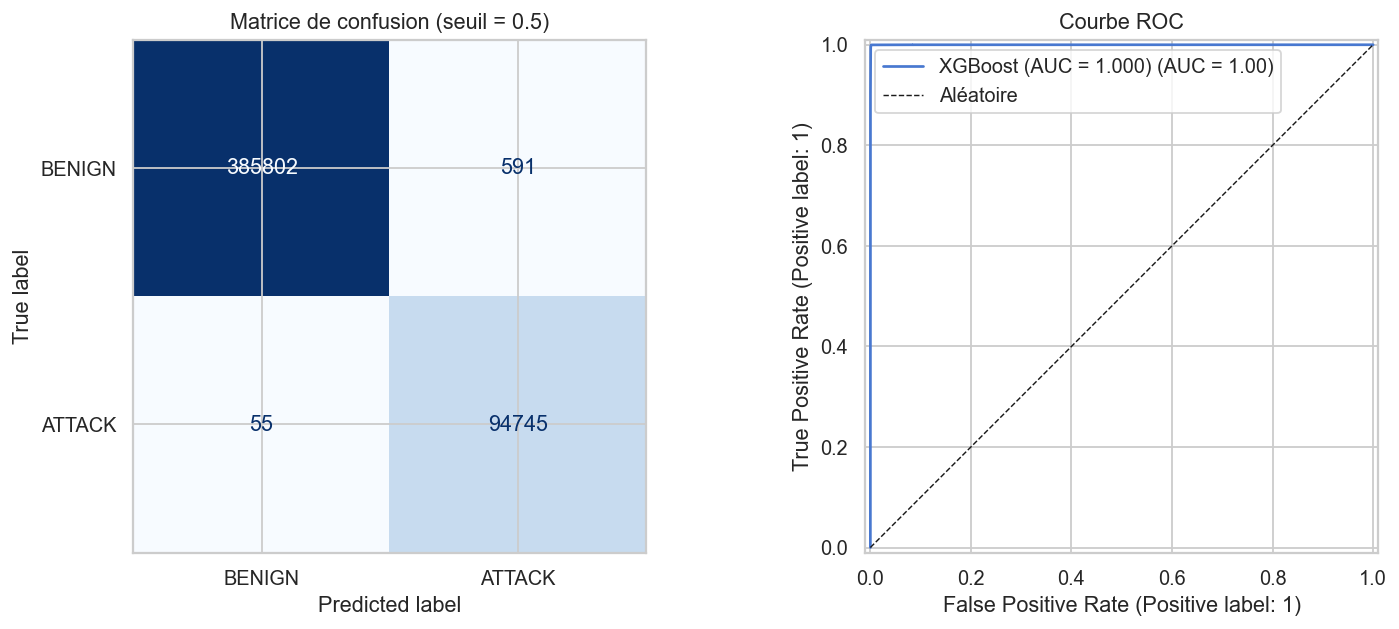

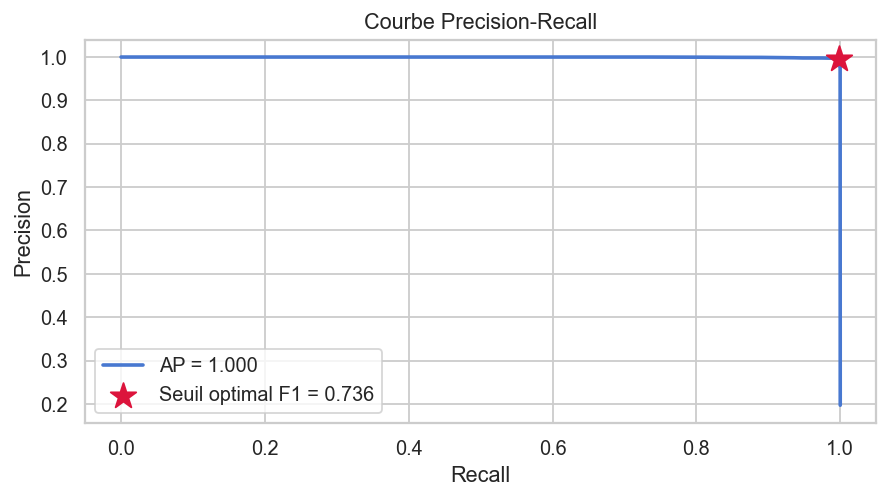

INFO │ Seuil optimal F1 : 0.736


In [ ]:
#new
# ── Confusion matrix + ROC ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_final, y_pred,
    display_labels = CLASS_NAMES,
    ax             = axes[0],
    colorbar       = False,
    cmap           = "Blues",
)
axes[0].set_title("Matrice de confusion (seuil = 0.5)")

RocCurveDisplay.from_predictions(
    y_test_final, y_prob,
    name = f"XGBoost (AUC = {auc:.3f})",
    ax   = axes[1],
)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aléatoire")
axes[1].set_title("Courbe ROC")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_roc.png", bbox_inches="tight")
plt.show()

# ── Courbe Précision-Rappel + seuil optimal F1 ───────────────────────────────
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test_final, y_prob)
f1_per_thresh  = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)
best_idx       = int(np.argmax(f1_per_thresh))
BEST_THRESHOLD = float(thresholds_arr[best_idx]) if best_idx < len(thresholds_arr) else 0.5

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recall_arr, precision_arr, linewidth=2, label=f"AP = {ap:.3f}")
ax.scatter(recall_arr[best_idx], precision_arr[best_idx],
           marker="*", s=220, color="crimson", zorder=5,
           label=f"Seuil optimal F1 = {BEST_THRESHOLD:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Courbe Precision-Recall")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "precision_recall.png", bbox_inches="tight")
plt.show()

metrics["optimal_threshold"] = BEST_THRESHOLD
log.info("Seuil optimal F1 : %.3f", BEST_THRESHOLD)

## §17 · Explicabilité SHAP

SHAP quantifie la contribution de chaque feature à **chaque prédiction individuelle**. On travaille sur un sous-échantillon de `SHAP_SAMPLE_SIZE` exemples pour limiter les temps de calcul.

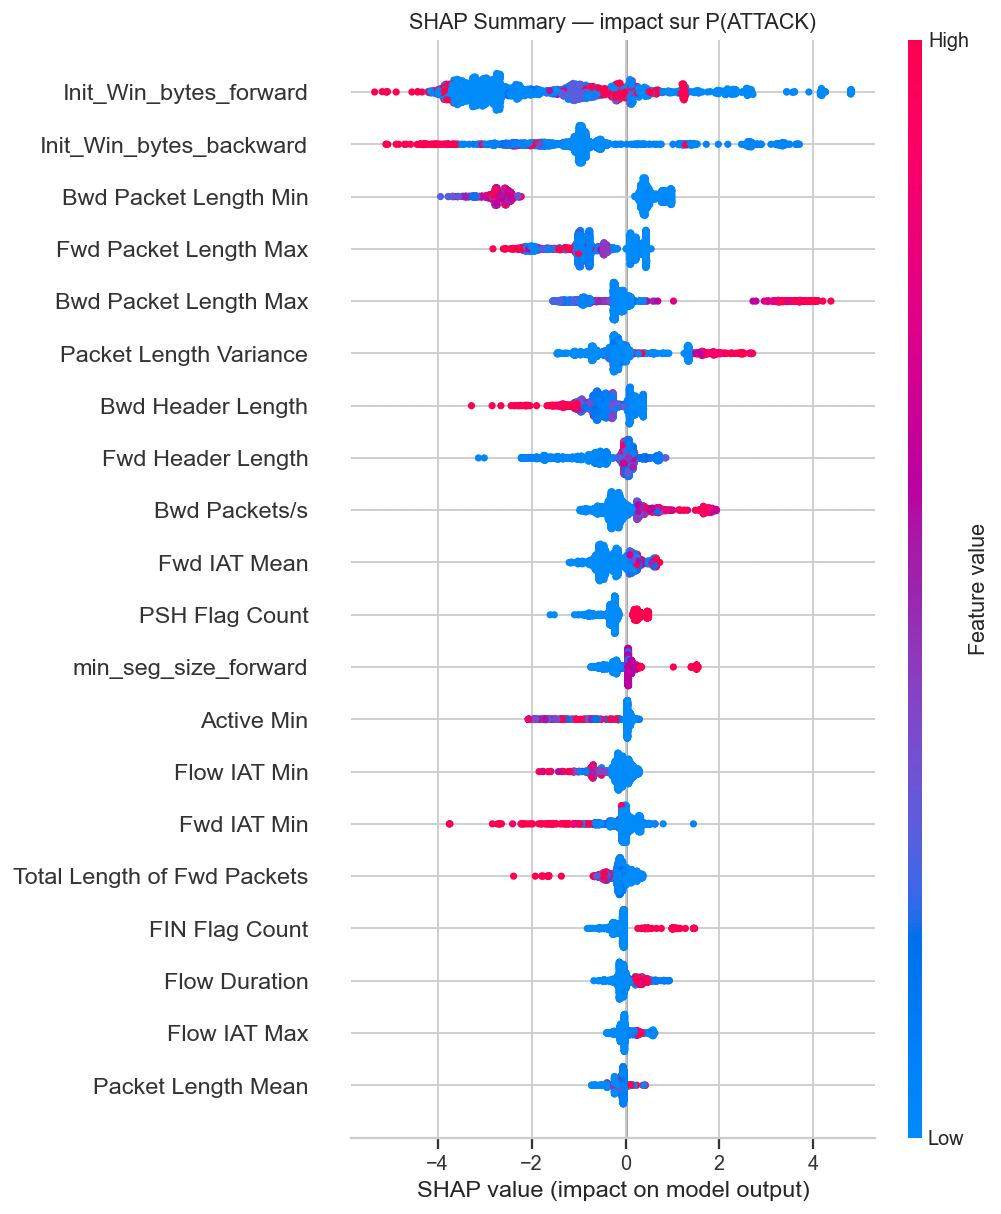

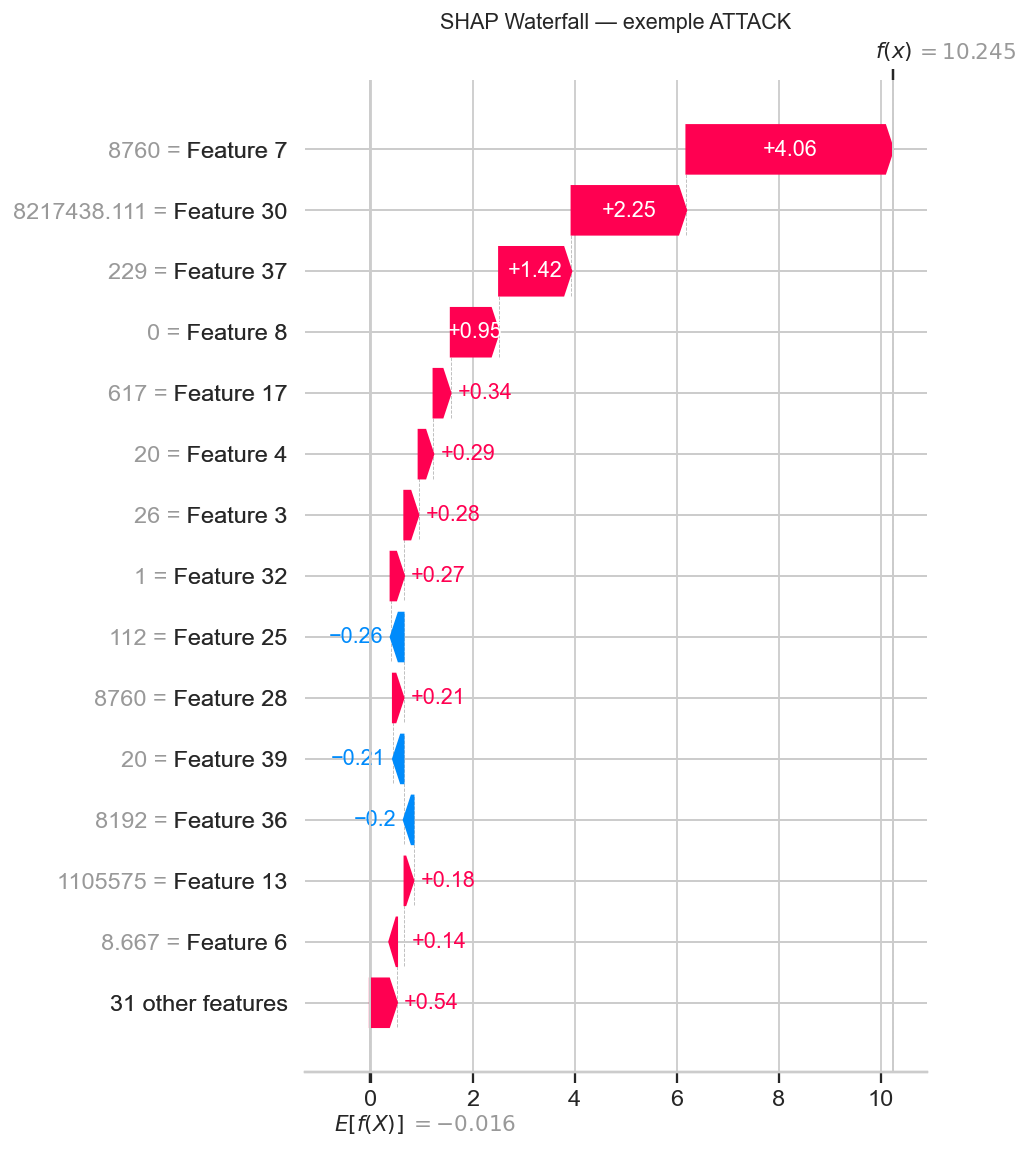

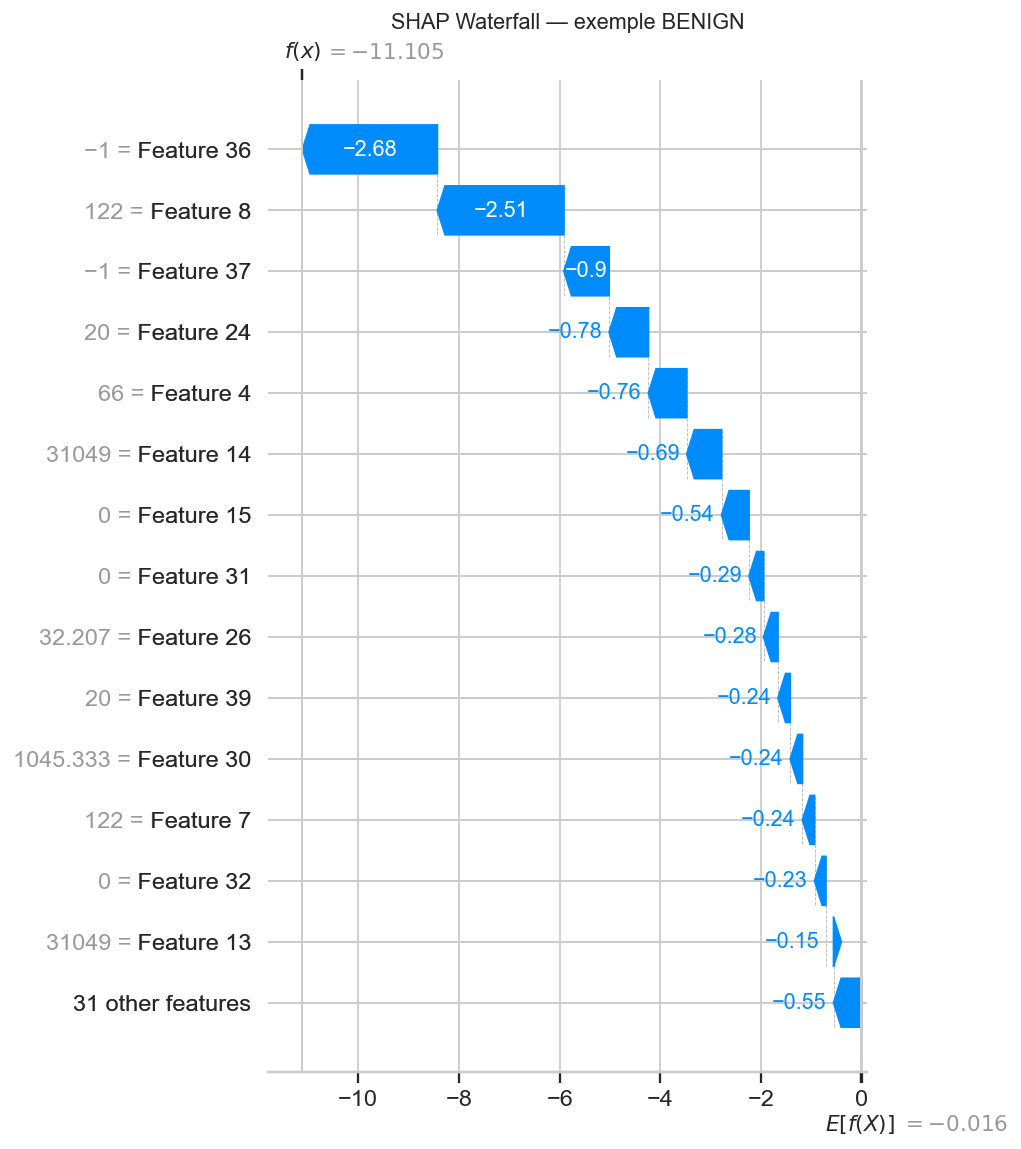

In [ ]:
# ── Sous-échantillon pour SHAP ────────────────────────────────────────────────
X_shap = X_test_final.sample(
    min(SHAP_SAMPLE_SIZE, len(X_test_final)),
    random_state = RANDOM_STATE,
)

explainer   = shap.TreeExplainer(baseline_model)
shap_values = explainer.shap_values(X_shap.values)

# ── Summary plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 8))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names = FEATURE_NAMES,
    max_display   = 20,
    show          = False,
)
plt.title("SHAP Summary — impact sur P(ATTACK)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary.png", bbox_inches="tight")
plt.show()

# ── Waterfall : décomposition d'une prédiction individuelle ──────────────────
sv_full       = explainer(X_shap.values)
sample_labels = y_test_final.loc[X_shap.index].values

for label, cls in [("ATTACK", 1), ("BENIGN", 0)]:
    indices = np.where(sample_labels == cls)[0]
    if len(indices) == 0:
        log.warning("Aucun exemple %s dans l'échantillon SHAP", label)
        continue
    idx = int(indices[0])
    plt.figure()
    shap.plots.waterfall(sv_full[idx], max_display=15, show=False)
    plt.title(f"SHAP Waterfall — exemple {label}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"shap_waterfall_{label.lower()}.png", bbox_inches="tight")
    plt.show()

## §18 · Logging MLflow

Toutes les métriques, paramètres et artefacts sont loggés dans une expérience MLflow pour traçabilité et comparaison de runs.

In [ ]:
#new
mlflow.set_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name="xgboost_baseline") as run:
    mlflow.log_params({
        **BASELINE_PARAMS,
        "n_boost_round" : best_baseline_iter,
        "objective"     : OBJECTIVE,
        "scale_pos_weight" : round(SCALE_POS_WEIGHT, 4),
        "train_rows"    : len(X_train),
        "n_features"    : len(FEATURE_NAMES),
    })
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(baseline_model, artifact_path="model")
    for img in sorted(OUTPUT_DIR.glob("*.png")):
        mlflow.log_artifact(str(img), artifact_path="plots")
    run_id = run.info.run_id
log.info("MLflow run_id: %s", run_id)

2026/05/18 06:29:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/18 06:29:51 INFO mlflow.store.db.utils: Updating database tables
2026/05/18 06:29:53 INFO mlflow.tracking.fluent: Experiment with name 'xgboost_ids' does not exist. Creating a new experiment.
2026/05/18 06:29:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
INFO │ MLflow run_id: 16f2b0195b484579a48a263b6d832152


## §19 · Sauvegarde des artefacts

Le modèle a déjà été sauvegardé au §12. Cette cellule complète la sauvegarde avec les métadonnées complètes.

## Métadonnées complètes en JSON
## Contient tout ce qu'il faut pour recharger et utiliser le modèle en inférence

In [ ]:
#mew
metadata = {
    "task"              : "binary_classification",
    "classes"           : CLASS_NAMES,
    "positive_class"    : "ATTACK",
    "feature_names"     : FEATURE_NAMES,
    "n_features"        : len(FEATURE_NAMES),
    "n_boost_round"     : best_baseline_iter,
    "optimal_threshold" : round(BEST_THRESHOLD, 4),
    "scale_pos_weight"  : round(SCALE_POS_WEIGHT, 4),
    "best_params"       : BASELINE_PARAMS,
    "mlflow_run_id"     : run_id,
    "metrics"           : {
        "test" : {k: round(float(v), 6) for k, v in metrics.items()},
    },
}

with open(OUTPUT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✓ Artefacts sauvegardés dans :", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"   {p.name:<40} {p.stat().st_size/1024:>7.1f} KB")

✓ Artefacts sauvegardés dans : C:\Users\Alae-School\Documents\model\outputs
   baseline_learning_curves.png                68.8 KB
   class_distribution.png                      36.6 KB
   confusion_roc.png                           61.1 KB
   metadata.json                                2.0 KB
   precision_recall.png                        27.1 KB
   shap_summary.png                           165.2 KB
   shap_waterfall_attack.png                   92.4 KB
   shap_waterfall_benign.png                   92.4 KB


In [ ]:
#save model
MODEL_PATH = OUTPUT_DIR / "model.ubj"
baseline_model.save_model(str(MODEL_PATH))
log.info("✓ Modèle sauvegardé → %s (%d arbres)", MODEL_PATH, best_baseline_iter)

INFO │ ✓ Modèle sauvegardé → outputs\model.ubj (47 arbres)


## §20 · Fonction d'inférence

Utilise automatiquement le seuil optimal trouvé sur la courbe PR. Compatible avec n'importe quel `DataFrame` ayant les mêmes colonnes que `X_train`.

In [ ]:
#new
def predict(X: pd.DataFrame, threshold: float = None) -> pd.DataFrame:
    """
    Inférence sur de nouvelles données pré-processées.
    Parameters
    ----------
    X         : DataFrame avec les mêmes colonnes que X_train
    threshold : seuil de décision (None → seuil optimal F1 calculé en §15)
    Returns
    -------
    DataFrame : probability | prediction | label
    """
    t    = threshold if threshold is not None else metrics.get("optimal_threshold", 0.5)
    dm   = xgb.DMatrix(X[FEATURE_NAMES], feature_names=FEATURE_NAMES)
    prob = baseline_model.predict(dm)
    pred = (prob >= t).astype(int)
    return pd.DataFrame({
        "probability" : prob.round(4),
        "prediction"  : pred,
        "label"       : [CLASS_NAMES[p] for p in pred],
    })

# ── Test rapide ───────────────────────────────────────────────────────────────
sample = predict(X_test_final.head(5))
sample["true_label"] = [CLASS_NAMES[v] for v in y_test_final.head(5).values]
sample["correct"]    = sample["label"] == sample["true_label"]
display(sample)


,probability,prediction,label,true_label,correct
0,0.0002,0,BENIGN,BENIGN,True
1,0.0002,0,BENIGN,BENIGN,True
2,0.0002,0,BENIGN,BENIGN,True
3,0.0000,0,BENIGN,BENIGN,True
4,0.0002,0,BENIGN,BENIGN,True


## §21 · Résumé final

In [ ]:
#new
print("\n" + "═" * 58)
print("  RÉSUMÉ DU PIPELINE")
print("═" * 58)
print(f"  Features            : {len(FEATURE_NAMES)}")
print(f"  Train               : {len(X_train):,} lignes")
print(f"  Test                : {len(X_test_final):,} lignes")
print(f"  scale_pos_weight    : {SCALE_POS_WEIGHT:.4f}")
print(f"  Arbres (final)      : {best_baseline_iter}")
print(f"  Seuil optimal F1    : {BEST_THRESHOLD:.3f}")
print()
print("  Métriques test set :")
for k, v in metrics.items():
    print(f"    {k:<24} {v:.4f}")
print("═" * 58)


══════════════════════════════════════════════════════════
  RÉSUMÉ DU PIPELINE
══════════════════════════════════════════════════════════
  Features            : 45
  Train               : 2,264,432 lignes
  Test                : 481,193 lignes
  scale_pos_weight    : 4.0759
  Arbres (final)      : 47
  Seuil optimal F1    : 0.736

  Métriques test set :
    accuracy                 0.9987
    f1                       0.9966
    mcc                      0.9958
    roc_auc                  0.9999
    avg_precision            0.9997
    optimal_threshold        0.7363
══════════════════════════════════════════════════════════
